# EDA of the merged listed dataset

## 1. Dataset Understanding

In [29]:
import pandas as pd 

df = pd.read_csv('../../processed/listed/listed_cleaned_v1.csv')

/var/folders/bn/snz6hdrs7gbfh48m_qnfs_dr0000gn/T/ipykernel_84270/1168260635.py:3: DtypeWarning: Columns (2,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../processed/listed/listed_cleaned_v1.csv')


In [30]:
print("Number of rows and columns:", df.shape)
print("\nColumn data types summary:")
print(df.dtypes.value_counts())
print("\nHigh-missing columns (>50% missing):")
missing_pct = df.isnull().sum() / len(df) * 100
high_missing = missing_pct[missing_pct > 50].sort_values(ascending=False)
print(high_missing)
print(f"\nTotal columns with >50% missing: {len(high_missing)}")

Number of rows and columns: (853424, 66)

Column data types summary:
object     43
float64    20
int64       3
Name: count, dtype: int64

High-missing columns (>50% missing):
CoBuyerAgentFirstName          97.661303
BuilderName                    96.567357
LotSizeDimensions              94.295684
ElementarySchool               90.710831
MiddleOrJuniorSchool           90.699465
HighSchool                     87.774893
BuyerAgencyCompensation        85.526655
BuyerAgencyCompensationType    85.524429
BuildingAreaTotal              83.970687
CoListAgentFirstName           80.042628
CoListAgentLastName            79.985447
CoListOfficeName               79.968808
ClosePrice                     72.349266
BuyerOfficeAOR                 72.321027
AssociationFeeFrequency        71.141074
BuyerOfficeName                70.910356
BuyerAgentFirstName            70.740921
BuyerAgentMlsId                70.721587
BuyerAgentLastName             70.633003
CloseDate                      69.698766
Subdi

In [31]:
print("All column names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

All column names:
 1. OriginalListPrice
 2. ListingKey
 3. ListAgentEmail
 4. CloseDate
 5. ClosePrice
 6. ListAgentFirstName
 7. ListAgentLastName
 8. Latitude
 9. Longitude
10. UnparsedAddress
11. PropertyType
12. LivingArea
13. ListPrice
14. DaysOnMarket
15. ListOfficeName
16. BuyerOfficeName
17. CoListOfficeName
18. ListAgentFullName
19. CoListAgentFirstName
20. CoListAgentLastName
21. BuyerAgentMlsId
22. BuyerAgentFirstName
23. BuyerAgentLastName
24. AssociationFeeFrequency
25. ListingKeyNumeric
26. MLSAreaMajor
27. CountyOrParish
28. MlsStatus
29. ElementarySchool
30. AttachedGarageYN
31. ParkingTotal
32. BuilderName
33. PropertySubType
34. LotSizeAcres
35. SubdivisionName
36. BuyerOfficeAOR
37. YearBuilt
38. BuyerAgencyCompensationType
39. StreetNumberNumeric
40. ListingId
41. BathroomsTotalInteger
42. City
43. BuyerAgencyCompensation
44. BuildingAreaTotal
45. BedroomsTotal
46. ContractStatusChangeDate
47. CoBuyerAgentFirstName
48. PurchaseContractDate
49. ListingContractDate
50

In [32]:
# Separate market analysis fields from metadata fields
market_analysis_fields = [
    'OriginalListPrice', 'ListPrice', 'ClosePrice', 'LivingArea', 'LotSizeAcres',
    'LotSizeArea', 'LotSizeSquareFeet', 'BuildingAreaTotal', 'BedroomsTotal',
    'BathroomsTotalInteger', 'MainLevelBedrooms', 'Latitude', 'Longitude',
    'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'PropertyType',
    'PropertySubType', 'YearBuilt', 'Stories', 'Levels', 'AttachedGarageYN',
    'ParkingTotal', 'GarageSpaces', 'FireplaceYN', 'NewConstructionYN', 'DaysOnMarket'
]

metadata_fields = [
    'ListingKey', 'ListingKeyNumeric', 'ListingId', 'ListAgentEmail',
    'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName',
    'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId',
    'BuyerAgentFirstName', 'BuyerAgentLastName', 'CoBuyerAgentFirstName',
    'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'BuyerOfficeAOR',
    'CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate',
    'ListingContractDate', 'UnparsedAddress', 'StreetNumberNumeric',
    'StateOrProvince', 'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
    'HighSchoolDistrict', 'SubdivisionName', 'BuilderName', 'AssociationFee',
    'AssociationFeeFrequency', 'BuyerAgencyCompensation',
    'BuyerAgencyCompensationType', 'LotSizeDimensions', 'MlsStatus',
    'source_file', 'source_month'
]

print("Market Analysis Fields:")
for field in market_analysis_fields:
    print(f"  - {field}")

print(f"\nTotal Market Analysis Fields: {len(market_analysis_fields)}")

print("\nMetadata Fields:")
for field in metadata_fields:
    print(f"  - {field}")

print(f"\nTotal Metadata Fields: {len(metadata_fields)}")

# Verify all columns are covered
all_classified = set(market_analysis_fields + metadata_fields)
all_columns = set(df.columns)
if all_classified == all_columns:
    print("\n✓ All columns have been classified.")
else:
    print(f"\n⚠ Unclassified columns: {all_columns - all_classified}")

Market Analysis Fields:
  - OriginalListPrice
  - ListPrice
  - ClosePrice
  - LivingArea
  - LotSizeAcres
  - LotSizeArea
  - LotSizeSquareFeet
  - BuildingAreaTotal
  - BedroomsTotal
  - BathroomsTotalInteger
  - MainLevelBedrooms
  - Latitude
  - Longitude
  - City
  - PostalCode
  - CountyOrParish
  - MLSAreaMajor
  - PropertyType
  - PropertySubType
  - YearBuilt
  - Stories
  - Levels
  - AttachedGarageYN
  - ParkingTotal
  - GarageSpaces
  - FireplaceYN
  - NewConstructionYN
  - DaysOnMarket

Total Market Analysis Fields: 28

Metadata Fields:
  - ListingKey
  - ListingKeyNumeric
  - ListingId
  - ListAgentEmail
  - ListAgentFirstName
  - ListAgentLastName
  - ListAgentFullName
  - CoListAgentFirstName
  - CoListAgentLastName
  - BuyerAgentMlsId
  - BuyerAgentFirstName
  - BuyerAgentLastName
  - CoBuyerAgentFirstName
  - ListOfficeName
  - BuyerOfficeName
  - CoListOfficeName
  - BuyerOfficeAOR
  - CloseDate
  - ContractStatusChangeDate
  - PurchaseContractDate
  - ListingContrac

## 2. Missing Value Analysis

In [33]:
missing_count = df.isnull().sum()
missing_pct = df.isnull().sum() / len(df) * 100

missing_report = pd.DataFrame({'missing_counts': missing_count, 'missing_pct': missing_pct})
missing_report = missing_report.sort_values(by='missing_pct', ascending=False) 

import numpy as np
missing_report['missing_flag'] = np.where(
    missing_report['missing_pct'] > 90,
    'high_missing',
    ''
) 
missing_report

,missing_counts,missing_pct,missing_flag
CoBuyerAgentFirstName,833465,97.661303,high_missing
BuilderName,824129,96.567357,high_missing
LotSizeDimensions,804742,94.295684,high_missing
ElementarySchool,774148,90.710831,high_missing
MiddleOrJuniorSchool,774051,90.699465,high_missing
...,...,...,...
ListingKeyNumeric,0,0.000000,
MlsStatus,0,0.000000,
ListingKey,0,0.000000,
ListingId,0,0.000000,


In [34]:
high_missing = missing_report[missing_report['missing_flag'] == 'high_missing']
high_missing

,missing_counts,missing_pct,missing_flag
CoBuyerAgentFirstName,833465,97.661303,high_missing
BuilderName,824129,96.567357,high_missing
LotSizeDimensions,804742,94.295684,high_missing
ElementarySchool,774148,90.710831,high_missing
MiddleOrJuniorSchool,774051,90.699465,high_missing


In [35]:
[c for c in df.columns if 'area' in c.lower() or 'sqft' in c.lower()]

['LivingArea', 'MLSAreaMajor', 'BuildingAreaTotal', 'LotSizeArea']

In [36]:
cols_to_drop = [
    'CoBuyerAgentFirstName',
    'BuilderName',
    'LotSizeDimensions',
    'BuildingAreaTotal'  
]

## 3. Numeric Distribution Review

In [37]:
numeric_cols = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']

In [38]:
for col in numeric_cols:
    print(df[col].value_counts())

ClosePrice
3500.0       2510
4500.0       1987
3200.0       1695
4000.0       1656
3000.0       1614
             ... 
1134750.0       1
1012094.0       1
3388888.0       1
5149500.0       1
2424030.0       1
Name: count, Length: 15139, dtype: int64
ListPrice
799000.0     6170
899000.0     5471
699000.0     5350
3500.0       5194
599000.0     4786
             ... 
2875888.0       1
408999.0        1
289600.0        1
1168744.0       1
999333.0        1
Name: count, Length: 31761, dtype: int64
OriginalListPrice
799000.0     6046
899000.0     5411
3500.0       5341
699000.0     5312
4500.0       4923
             ... 
725950.0        1
1491340.0       1
1487500.0       1
514303.0        1
999333.0        1
Name: count, Length: 31767, dtype: int64
LivingArea
1440.0     4946
1200.0     4772
1000.0     4351
800.0      3434
1100.0     3316
           ... 
13787.0       1
9590.0        1
6075.0        1
14917.0       1
10909.0       1
Name: count, Length: 9967, dtype: int64
LotSizeAcres
0.00

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Identify all numeric columns
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Total numeric columns: {len(numeric_cols_all)}")
print(numeric_cols_all)

Total numeric columns: 23
['OriginalListPrice', 'ListingKey', 'ClosePrice', 'Latitude', 'Longitude', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListingKeyNumeric', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'BuyerAgencyCompensation', 'BuildingAreaTotal', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet']


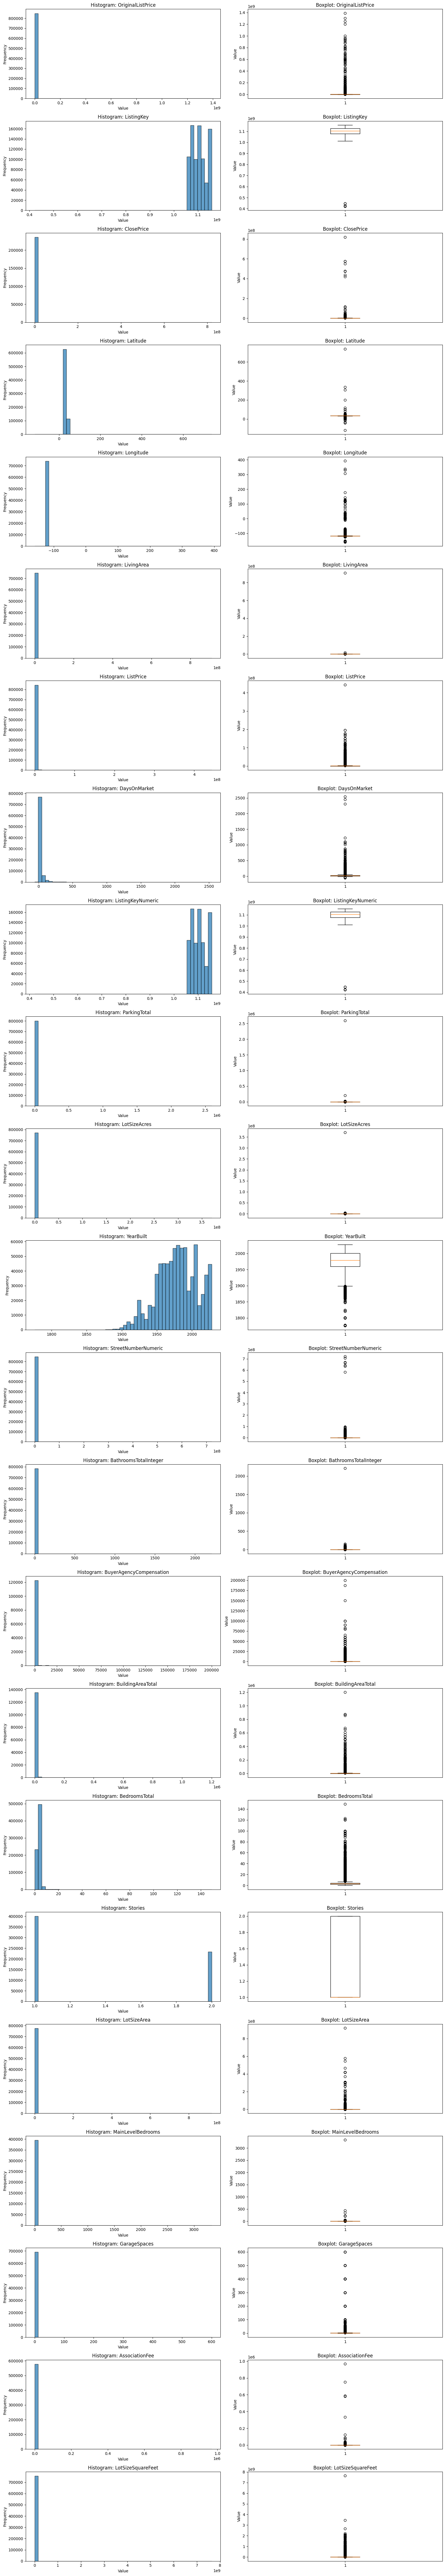

In [40]:
# Create comprehensive numeric analysis
fig, axes = plt.subplots(len(numeric_cols_all), 2, figsize=(16, 4*len(numeric_cols_all)))

for idx, col in enumerate(numeric_cols_all):
    # Histogram
    axes[idx, 0].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Histogram: {col}')
    axes[idx, 0].set_xlabel('Value')
    axes[idx, 0].set_ylabel('Frequency')
    
    # Boxplot
    axes[idx, 1].boxplot(df[col].dropna(), vert=True)
    axes[idx, 1].set_title(f'Boxplot: {col}')
    axes[idx, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [41]:
# Generate percentile summaries and outlier analysis
print("=" * 80)
print("PERCENTILE SUMMARIES AND OUTLIER DETECTION")
print("=" * 80)

outliers_summary = []

for col in numeric_cols_all:
    print(f"\n{col}:")
    print("-" * 80)
    
    # Get non-null values
    valid_data = df[col].dropna()
    
    if len(valid_data) == 0:
        print("  No valid data")
        continue
    
    # Percentile summary
    percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]
    print("\nPercentile Summary:")
    for p in percentiles:
        value = np.percentile(valid_data, p)
        print(f"  {p:3d}th percentile: {value:15,.2f}")
    
    # Basic statistics
    print(f"\nBasic Statistics:")
    print(f"  Mean:     {valid_data.mean():15,.2f}")
    print(f"  Median:   {valid_data.median():15,.2f}")
    print(f"  Std Dev:  {valid_data.std():15,.2f}")
    print(f"  Min:      {valid_data.min():15,.2f}")
    print(f"  Max:      {valid_data.max():15,.2f}")
    
    # IQR-based outlier detection
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = valid_data[(valid_data < lower_bound) | (valid_data > upper_bound)]
    
    # Extreme outliers (beyond 3*IQR)
    extreme_lower = Q1 - 3 * IQR
    extreme_upper = Q3 + 3 * IQR
    extreme_outliers = valid_data[(valid_data < extreme_lower) | (valid_data > extreme_upper)]
    
    print(f"\nOutlier Analysis (IQR method):")
    print(f"  IQR:           {IQR:15,.2f}")
    print(f"  Lower Bound:   {lower_bound:15,.2f}")
    print(f"  Upper Bound:   {upper_bound:15,.2f}")
    print(f"  Outliers:      {len(outliers):15,} ({len(outliers)/len(valid_data)*100:5.2f}%)")
    print(f"  Extreme Lower: {extreme_lower:15,.2f}")
    print(f"  Extreme Upper: {extreme_upper:15,.2f}")
    print(f"  Extreme Outliers: {len(extreme_outliers):10,} ({len(extreme_outliers)/len(valid_data)*100:5.2f}%)")
    
    outliers_summary.append({
        'Column': col,
        'Total_Values': len(valid_data),
        'Outliers_Count': len(outliers),
        'Outliers_Percent': f"{len(outliers)/len(valid_data)*100:.2f}%",
        'Extreme_Outliers': len(extreme_outliers),
        'Extreme_Percent': f"{len(extreme_outliers)/len(valid_data)*100:.2f}%"
    })

PERCENTILE SUMMARIES AND OUTLIER DETECTION

OriginalListPrice:
--------------------------------------------------------------------------------

Percentile Summary:
    0th percentile:            0.00
    1th percentile:        1,800.00
    5th percentile:        2,850.00
   25th percentile:       85,000.00
   50th percentile:      639,888.00
   75th percentile:    1,150,000.00
   95th percentile:    2,999,999.00
   99th percentile:    7,495,000.00
  100th percentile: 1,390,000,000.00

Basic Statistics:
  Mean:        1,050,855.78
  Median:        639,888.00
  Std Dev:     6,389,980.52
  Min:                 0.00
  Max:      1,390,000,000.00

Outlier Analysis (IQR method):
  IQR:              1,065,000.00
  Lower Bound:     -1,512,500.00
  Upper Bound:      2,747,500.00
  Outliers:               52,444 ( 6.17%)
  Extreme Lower:   -3,110,000.00
  Extreme Upper:    4,345,000.00
  Extreme Outliers:     22,288 ( 2.62%)

ListingKey:
----------------------------------------------------------

In [42]:
# Summary table of outliers
outliers_df = pd.DataFrame(outliers_summary)
print("\n" + "=" * 80)
print("OUTLIER SUMMARY TABLE")
print("=" * 80)
print(outliers_df.to_string(index=False))


OUTLIER SUMMARY TABLE
                 Column  Total_Values  Outliers_Count Outliers_Percent  Extreme_Outliers Extreme_Percent
      OriginalListPrice        850112           52444            6.17%             22288           2.62%
             ListingKey        853424               5            0.00%                 5           0.00%
             ClosePrice        235978           10311            4.37%              3423           1.45%
               Latitude        741494          168762           22.76%            115388          15.56%
              Longitude        742198          121624           16.39%             28738           3.87%
             LivingArea        746124           40250            5.39%             14063           1.88%
              ListPrice        851283           51263            6.02%             21556           2.53%
           DaysOnMarket        853424           76579            8.97%             41235           4.83%
      ListingKeyNumeric        8

## 4. Answer Questions

### Q1: What is the Residential vs. other property type share?

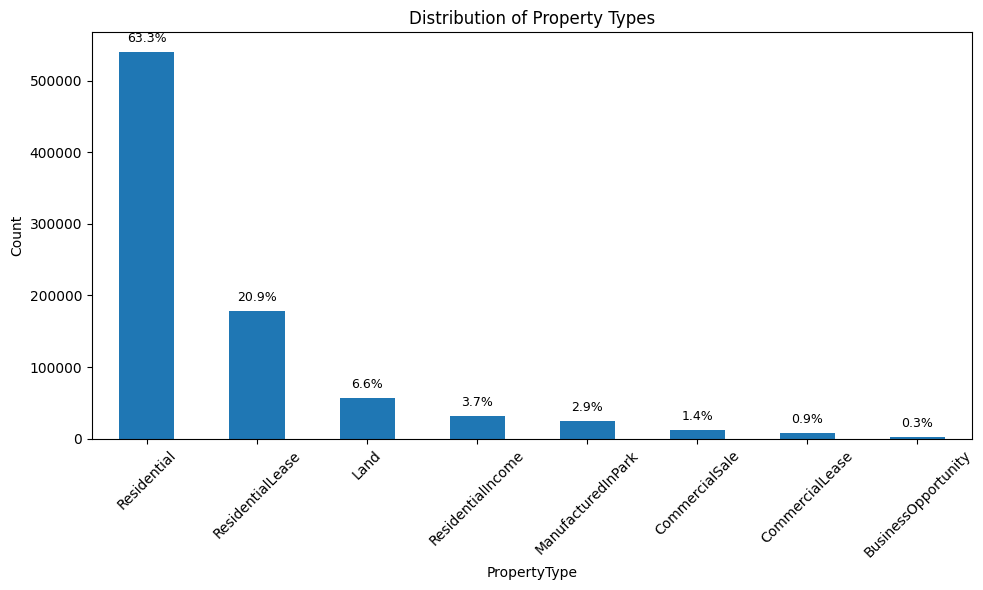

In [47]:
propertytype = df['PropertyType'].value_counts()
total = propertytype.sum()
ax = propertytype.plot(kind='bar', figsize=(10,6), title='Distribution of Property Types')
plt.ylabel('Count')
plt.xticks(rotation=45)

for p in ax.patches:
    height = p.get_height()
    pct = height / total * 100
    ax.annotate(f'{pct:.1f}%',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Q2: What are the median and average close prices?

Answer with the sold dataset.

### Q3: What does the Days on Market distribution look like?

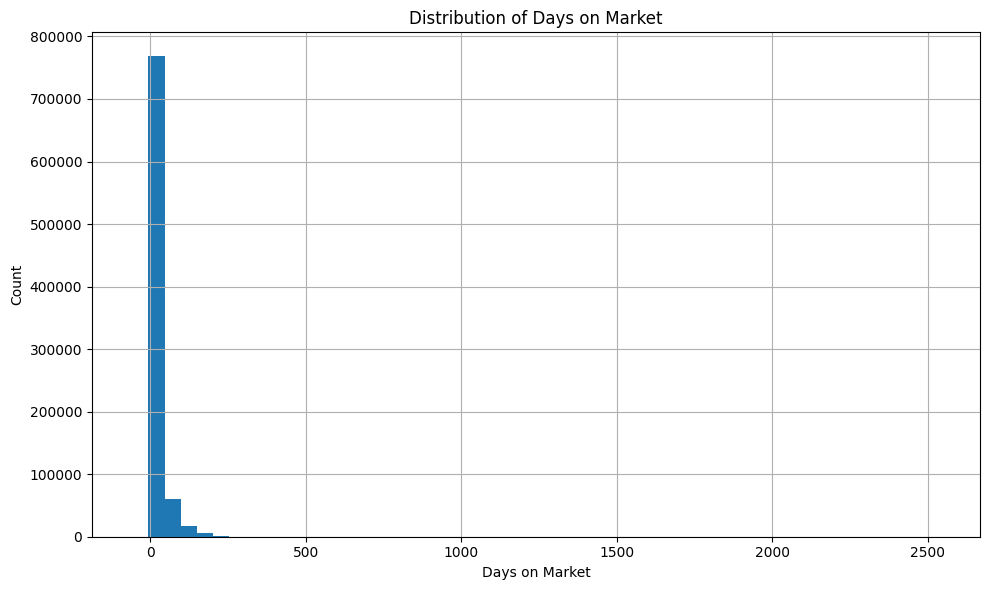

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df['DaysOnMarket'].hist(bins=50)
# df[df['DaysOnMarket'] <= 200]['DaysOnMarket'].hist(bins=50)

plt.title('Distribution of Days on Market')
plt.xlabel('Days on Market')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Q4: What percentage of homes sold above vs. below list price?

Answer with the sold dataset.

### Q5: Are there any apparent date consistency issues (e.g., close date before listing date)?

In [57]:
df_q5 = df.dropna(subset=['CloseDate', 'ListingContractDate']).copy()

df_q5['CloseDate'] = pd.to_datetime(df_q5['CloseDate'])
df_q5['ListingContractDate'] = pd.to_datetime(df_q5['ListingContractDate'])

invalid_dates = df_q5[df_q5['CloseDate'] < df_q5['ListingContractDate']]

print(f"Inconsistent records: {len(invalid_dates)}")
print(f"Percentage: {len(invalid_dates) / len(df_q5) * 100:.2f}%")

Inconsistent records: 135
Percentage: 0.05%


These records may be removed in a later cleaning stage.

### Q6: Which counties have the highest median prices?

Answer with the sold dataset.

In [59]:
df[['ClosePrice', 'CloseDate', 'ListPrice']].isna().mean()

ClosePrice    0.723493
CloseDate     0.696988
ListPrice     0.002509
dtype: float64

Listings don't have enough ClosePrice data (~30% of records), so the Q2, Q4, Q6 will be answered with the sold dataset.